---
numbering: false
---

# 10.1. Computing the Singular Value Decomposition

Eigenvalues and eigenvectors are powerful concepts, but unfortunately, they only apply to square matrices. It would be nice if we could extend some of their utility to non-square matrices, like matrices containing real data, which typically have many more rows than columns.

---

## Introduction

This is precisely where the **singular value decomposition** (SVD) comes in. You should think of it as a generalization of the eigenvalue decomposition, $A = V \Lambda V^{-1}$, to non-square matrices. When we first introduced eigenvalues and eigenvectors, we said that an eigenvector $\vec v$ of $A$ is a vector whose direction is unchanged when multiplied by $A$ – all that happens to $\vec v$ is that it's scaled by a factor of $\mathcal{\lambda}$.

$$A \vec v = \lambda \vec v$$

But now, suppose $X$ is some $n \times d$ matrix. For any vector $\vec v \in \mathbb{R}^d$, the vector $X \vec v$ is in $\mathbb{R}^n$, **not** $\mathbb{R}^d$, meaning $\vec v$ and $X \vec v$ live in different universes. So, it can't make sense to say that $X \vec v$ results from stretching $\vec v$.

Instead, we'll find pairs of **singular vectors**, $\vec v \in \mathbb{R}^d$ and $\vec u \in \mathbb{R}^n$, such that

$$X \vec v = \sigma \vec u$$

where $\mathcal{\sigma}$ is a **singular value** of $A$ (not a standard deviation!). Intuitively, this says that when $X$ is multiplied by $\vec v$, the result is a scaled version of $\vec u$. These singular values and vectors are the focus of this chapter. Applications of the singular value decomposition will start in [Chapter 10.2](./02-low-rank-approximation.ipynb) – but go scroll to the bottom of that section if you want to see what we're working towards.

Think of $\vec u$, $\vec v$, and $\sigma$ – or perhaps better $\vec u_i$, $\vec v_i$, and $\sigma_i$ – as a trio of friends that appear together in the SVD of $X$; each matrix $X$ has $r$ such trios, where $r$ is the rank of $X$.

I'll start by giving you the definition of the SVD, and then together we'll figure out where it came from.

:::{note} Definition: Singular Value Decomposition
Suppose $X$ is any $n \times d$ matrix (that is, **not necessarily square**). Then, there exists a **singular value decomposition** of $X$ of the form

$$X = U \Sigma V^T$$

where:
- $U$ is an $n \times n$ orthogonal matrix, whose columns are called the **left singular vectors** of $X$
- $\mathcal{\Sigma}$ is an $n \times d$ diagonal matrix with non-negative real numbers on the diagonal and zeros elsewhere
- $V$ is a $d \times d$ orthogonal matrix, whose columns are called the **right singular vectors** of $X$

The diagonal entries of $\mathcal{\Sigma}$ are called the **singular values** of $X$. Typically, the singular values are sorted in decreasing order, i.e. $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$, where $r = \text{rank}(X)$.
:::

Firstly, note that the SVD exists, no matter what $X$ is: it can be non-square, and it doesn't even need to be full rank. But note that unlike in the eigenvalue decomposition, where we decomposed $A$ using just one eigenvector matrix $V$ and a diagonal matrix $\mathcal{\Lambda}$, here we need to use two **singular vector** matrices $U$ and $V$ and a diagonal matrix $\mathcal{\Sigma}$.

There's a lot of notation and new concepts above. Let's start with an example, then try and understand where each piece in $X = U \Sigma V^T$ comes from and means. Suppose

$$
X = \begin{bmatrix}
3 & 2 & 5 \\
2 & 3 & 5 \\
2 & -2 & 0 \\
5 & 5 & 10
\end{bmatrix}
$$

$X$ is a $4 \times 3$ matrix with $\text{rank}(X) = 2$, since its third column is the sum of the first two. Its singular value decomposition is given by $X = U \Sigma V^T$:

$$X = \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

Two important observations:

1. $U$ and $V$ are both orthogonal matrices, meaning $U^TU = UU^T = I_{4 \times 4}$ and $V^TV = VV^T = I_{3 \times 3}$.
1. $\mathcal{\Sigma}$ contains the singular values of $X$ on the diagonal, arranged in decreasing order. We have that $\sigma_1 = 15$, $\sigma_2 = 3$, and $\sigma_3 = 0$. $X$ has three singular values, but only two are non-zero. **In general, the number of non-zero singular values is equal to the rank of $X$**.

Where did all of these numbers come from?

---

## Discovering the SVD

The SVD of $X$ depends heavily on the matrices $X^TX$ and $XX^T$. While $X$ itself is $4 \times 3$, 
- $X^TX$ is a **symmetric $3 \times 3$ matrix**, containing the dot products of $X$'s columns
- $XX^T$ is a **symmetric $4 \times 4$ matrix**, containing the dot products of $X$'s rows

Since $X^TX$ and $XX^T$ are both square matrices, they have eigenvalues and eigenvectors. And since they're both symmetric, their eigenvectors for different eigenvalues are orthogonal to each other, as the spectral theorem $A = Q \Lambda Q^T$ guarantees for any symmetric matrix $A$. 

### Singular Values and Singular Vectors

The singular value decomposition involves creatively using the eigenvalues and eigenvectors of $X^TX$ and $XX^T$. Suppose $X = U \Sigma V^T$ is the SVD of $X$. Then, using the facts that $U^TU = I$ and $V^TV = I$, we have:

$$X^TX = (U \Sigma V^T)^T (U \Sigma V^T) = V \Sigma^T \underbrace{U^T U}_{I} \Sigma V^T = \underbrace{V \Sigma^T \Sigma V^T}_{\text{looks like } Q \Lambda Q^T}$$

$$XX^T = (U \Sigma V^T) (U \Sigma V^T)^T = U \Sigma \underbrace{V^T V}_{I} \Sigma^T U^T = \underbrace{U \Sigma \Sigma^T U^T}_{\text{looks like } P \Lambda P^T}$$

**This just looks like we diagonalized $X^TX$ and $XX^T$!** The expressions above are saying that:
- $V$'s columns are the eigenvectors of $X^TX$
- $U$'s columns are the eigenvectors of $XX^T$

$X^TX$ and $XX^T$ usually have different sets of eigenvectors, which is why $U$ and $V$ are generally not the same matrix (they don't even have the same shape).

The eigen**values** of $X^TX$ and $XX^T$ **are the same**, though: those are the non-zero entries of $\Sigma^T \Sigma$ and $\Sigma \Sigma^T$. Since $\mathcal{\Sigma}$ is an $n \times d$ matrix, $\Sigma^T \Sigma$ is a $d \times d$ matrix and $\Sigma \Sigma^T$ is an $n \times n$ matrix. But, when you work out both products, you'll notice that their non-zero values are the same.

Suppose for example that $\Sigma = \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix}$. Then,

$$\Sigma^T \Sigma = \begin{bmatrix} \sigma_1 & 0 & 0 & 0 \\ 0 & \sigma_2 & 0 & 0 \\ 0 & 0 & \sigma_3 & 0 \end{bmatrix} \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix} = \begin{bmatrix} \sigma_1^2 & 0 & 0 \\ 0 & \sigma_2^2 & 0 \\ 0 & 0 & \sigma_3^2\end{bmatrix}$$

$$\Sigma \Sigma^T = \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix} \begin{bmatrix} \sigma_1 & 0 & 0 & 0 \\ 0 & \sigma_2 & 0 & 0 \\ 0 & 0 & \sigma_3 & 0 \end{bmatrix} = \begin{bmatrix} \sigma_1^2 & 0 & 0 & 0 \\ 0 & \sigma_2^2 & 0 & 0 \\ 0 & 0 & \sigma_3^2 & 0 \\ 0 & 0 & 0 & 0 \end{bmatrix}$$

But, these matrices with the squared terms are precisely the $\mathcal{\Lambda}$'s in the spectral decompositions of $X^TX = Q \Lambda Q^T$ and $XX^T = P \Lambda P^T$. This means that $$\sigma_i^2 = \lambda_i \implies \sigma_i = \sqrt{\lambda_i}$$

where $\sigma_i$ is a singular value of $X$ and $\lambda_i$ is an eigenvalue of $X^TX$ or $XX^T$.

The above derivation is enough to justify that the eigenvalues of $X^TX$ and $XX^T$ are never negative, but for another perspective, note that both $X^TX$ and $XX^T$ are **positive semidefinite**, meaning their eigenvalues are non-negative. (You're wrestling with this fact in Lab 11 and Homework 10.)

:::{attention} The relationship between singular values/vectors and eigenvalues/vectors

To summarize: in $X = U \Sigma V^T$,
- The columns of $U$ – called the **left singular vectors** of $X$ – are the eigenvectors of $XX^T$
- The columns of $V$ – called the **right singular vectors** of $X$ – are the eigenvectors of $X^TX$
- The **singular values** of $X$, which live on the diagonal of $\mathcal{\Sigma}$, are the **square roots of the eigenvalues** of $X^TX$ and $XX^T$: $$\sigma_i = \sqrt{\lambda_i}$$
:::


:::{tip} Another proof that $X^TX$ and $XX^T$ have the same non-zero eigenvalues
:class: dropdown

Above, we implicitly used the fact that $X^TX$ and $XX^T$ have the same non-zero eigenvalues. Here's a proof of this fact that has nothing to do with the SVD.

Suppose $\vec v_i$ is an eigenvector of $X^TX$ with eigenvalue $\lambda_i$.

$$X^TX \vec v_i = \lambda_i \vec v_i$$

What happens if we multiply both sides on the left by $X$?

$$XX^TX \vec v_i = X \lambda_i \vec v_i$$

Creatively adding parentheses gives us

$$XX^T (X \vec v_i) = \lambda_i (X \vec v_i)$$

This shows that $X \vec v_i$ is an eigenvector of $XX^T$ with eigenvalue $\lambda_i$. The important thing is that the eigenvalue is shared. This logic can be reversed too, to show that if $\vec u_i$ is an eigenvector of $XX^T$ with eigenvalue $\lambda_i$, then $\lambda_i$ is also an eigenvalue of $X^TX$.
:::

### Computing the SVD

To find $U$, $\mathcal{\Sigma}$, and $V^T$, we don't actually need to compute both $X^TX$ and $XX^T$: all of these quantities can be uncovered just with one of them.

Let's return to our example, $X = \begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}$. Using what we've just learned, let's find $U$, $\mathcal{\Sigma}$, and $V^T$ ourselves. $X^TX$ has fewer entries than $XX^T$, so let's start with it. I will delegate _some_ number crunching to `numpy`.

In [1]:
import numpy as np

X = np.array([[3, 2, 5],
              [2, 3, 5],
              [2, -2, 0],
              [5, 5, 10]])
X.T @ X

array([[ 42,  33,  75],
       [ 33,  42,  75],
       [ 75,  75, 150]])

$X^TX$ is a $3 \times 3$ matrix, but its rank is 2, meaning it will have an eigenvalue of $0$. What are its other eigenvalues?

In [2]:
np.set_printoptions(precision=0, suppress=True)

In [3]:
eigvals, eigvecs = np.linalg.eig(X.T @ X)
eigvals

array([225.,   9.,   0.])

The eigenvalues of $X^TX$ are $225$, $9$, and $0$. This tells us that the singular values of $X$ are $\sqrt{225} = 15$, $\sqrt{9} = 3$, and $0$. So far, we've discovered that $\mathcal{\Sigma} = \begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}$. Remember that $\mathcal{\Sigma}$ always has the same shape as $X$ (both are $n \times d$), and all of its entries are 0 except for the singular values, which are arranged in decreasing order on the diagonal, starting with the largest singular value in the top left corner.

Let's now find the eigenvectors of $X^TX$ – that is, the right singular vectors of $X$ – which we should store in $V$. **We expect the eigenvectors $\vec v_i$ of $X^TX$to be orthogonal**, since $X^TX$ is symmetric.

In [4]:
X.T @ X

array([[ 42,  33,  75],
       [ 33,  42,  75],
       [ 75,  75, 150]])

- For $\lambda_1 = 225$, one eigenvector is $\vec v_1 = \begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix}$, since

$$\underbrace{\begin{bmatrix} 42 & 33 & 75 \\ 33 & 42 & 75 \\ 75 & 75 & 150 \end{bmatrix}}_{X^TX} \begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix} = \begin{bmatrix} 225 \\ 225 \\ 450 \end{bmatrix} = 225 \begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix}$$

- For $\lambda_2 = 9$, one eigenvector is $\vec v_2 = \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$, since

$$\begin{bmatrix} 42 & 33 & 75 \\ 33 & 42 & 75 \\ 75 & 75 & 150 \end{bmatrix} \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix} = \begin{bmatrix} 9 \\ -9 \\ 0 \end{bmatrix} = 9 \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix}$$

- For $\lambda_3 = 0$, one eigenvector is $\vec v_3 = \begin{bmatrix} 1 \\ 1 \\ -1 \end{bmatrix}$, since

$$\begin{bmatrix} 42 & 33 & 75 \\ 33 & 42 & 75 \\ 75 & 75 & 150 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \\ -1 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

Note that $\vec v_3$ is a basis for $\text{nullsp}(X)$, since $\text{dim}(\text{nullsp}(X)) = 1$ and $X \vec v_3 = \vec 0$. Hold that thought for now.

To create $V$, all we need to do is turn $\vec v_1$, $\vec v_2$, and $\vec v_3$ into unit vectors.

$$\begin{bmatrix} 1 \\ 1 \\ 2 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} \\ \frac{1}{\sqrt{6}} \\ \frac{2}{\sqrt{6}} \end{bmatrix}}_{\vec v_1}, \quad \begin{bmatrix} 1 \\ -1 \\ 0 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \\ 0 \end{bmatrix}}_{\vec v_2}, \quad \begin{bmatrix} 1 \\ 1 \\ -1 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} \frac{1}{\sqrt{3}} \\ \frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \end{bmatrix}}_{\vec v_3}$$

Stacking these unit vectors together gives us $V$:

$$V = \begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{3}} \\ 
                      \frac{1}{\sqrt{6}} & -\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{3}} \\ 
                      \frac{2}{\sqrt{6}} & 0 & -\frac{1}{\sqrt{3}} \end{bmatrix}$$

And indeed, since $X^TX$ is symmetric, $V$ is orthogonal: $V^TV = VV^T = I_{3 \times 3}$.

Great! We're almost done computing the SVD. So far, we have

$$\underbrace{\begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}}_X = U \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

### $XV = U \Sigma$ and $X \vec v_i = \sigma_i \vec u_i$

Ideally, we can avoid having to compute the eigenvectors of $XX^T$ to stack into $U$. And we can. If we start with

$$X = U \Sigma V^T$$

and multiply both sides on the right by $V$, we uncover a relationship between the columns of $U$ and the columns of $V$.

$$XV = U \Sigma$$

Let's unpack this. On the left, the matrix $XV$ is made up of multiplying $X$ by each column of $V$.

$$XV = X_{4 \times 3} \begin{bmatrix} | & | & | \\ \vec v_1 & \vec v_2 & \vec v_3 \\ | & | & | \end{bmatrix}_{3 \times 3} = \begin{bmatrix} | & | & | \\ X \vec v_1 & X \vec v_2 & X \vec v_3 \\ | & | & | \end{bmatrix}_{4 \times 3}$$

On the right, $U \Sigma$ is made up of stretching each column of $U$ by the corresponding singular value in the diagonal of $\mathcal{\Sigma}$.

$$U \Sigma = \begin{bmatrix} | & | & | & | \\ \vec u_1 & \vec u_2 & \vec u_3 & \vec u_4 \\ | & | & | & | \end{bmatrix}_{4 \times 4} \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \\ 0 & 0 & 0 \end{bmatrix}_{4 \times 3} = \begin{bmatrix} | & | & | \\ \sigma_1 \vec u_1 & \sigma_2 \vec u_2 & \sigma_3 \vec u_3 \\ | & | & | \end{bmatrix}_{4 \times 3}$$

But, since $XV = U \Sigma$, we have

$$\begin{bmatrix} | & | & | \\ X \vec v_1 & X \vec v_2 & X \vec v_3 \\ | & | & | \end{bmatrix} = \begin{bmatrix} | & | & | \\ \sigma_1 \vec u_1 & \sigma_2 \vec u_2 & \sigma_3 \vec u_3 \\ | & | & | \end{bmatrix}$$

:::{attention} Singular values represent stretches, too!
A consequence of the above relationship is that if $X$ is $n \times d$, then for $i = 1, 2, ..., d$,

$$X \vec v_i = \sigma_i \vec u_i$$

**The above is saying that when $X$ is multiplied by $\vec v_i$, the result is a scaled version of $\vec u_i$ (not $\vec v_i$)!**

As we said at the start of the section, $X \vec v_i$ lives in a different universe $(\mathbb{R}^n)$ than $\vec v_i$ does $(\mathbb{R}^d)$, so $\vec v_i$ and $X \vec v_i$ can't point in the same direction; instead, $X \vec v_i$ points in the same direction as $\vec u_i$, which lives in $\mathbb{R}^n$. I like to think of each $\vec v_i$ having a "partner" $\vec u_i$; multiplying $X$ by $\vec v_i$ results in stretching $\vec u_i$.

$X \vec v_i = \sigma_i \vec u_i$ is the singular value/vector analog of $A \vec v = \lambda \vec v$ for eigenvalues/eigenvectors.
:::

**Crucially though**, $X \vec v_i = \sigma_i \vec u_i$ only holds when we've arranged the singular values and vectors in $U$, $\mathcal{\Sigma}$, and $V^T$ consistently. This is one reason why we always arrange the singular values in $\mathcal{\Sigma}$ in decreasing order.

Back to our example. Again, we currently have

$$\underbrace{\begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}}_X = U \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

We know $X$, and we know each $\vec v_i$ and $\sigma_i$. Rearranging $X \vec v_i = \sigma_i \vec u_i$ gives us

$$\vec u_i = \frac{1}{\sigma_i} X \vec v_i$$

which is a recipe for computing $\vec u_1$, $\vec u_2$, and $\vec u_3$.

1. $\vec u_1 = \frac{1}{15} X \begin{bmatrix} \frac{1}{\sqrt{6}} \\ \frac{1}{\sqrt{6}} \\ \frac{2}{\sqrt{6}} \end{bmatrix} = \begin{bmatrix} \frac{1}{\sqrt{6}} \\ \frac{1}{\sqrt{6}} \\ 0 \\ \frac{2}{\sqrt{6}} \end{bmatrix}$
1. $\vec u_2 = \frac{1}{3} X \begin{bmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \\ 0 \end{bmatrix} = \begin{bmatrix} \frac{1}{3\sqrt{2}} \\ -\frac{1}{3\sqrt{2}} \\ \frac{2\sqrt{2}}{3} \\ 0 \end{bmatrix}$
1. $\vec u_3 = \frac{1}{0} X \begin{bmatrix} \frac{1}{\sqrt{3}} \\ \frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \end{bmatrix} = ... \text{wait, what?}$

Something is not quite right: $\sigma_3 = 0$, which means we can't use $\vec u_i = \frac{1}{\sigma_i} X \vec v_i$ to compute $\vec u_3$. And, even if we could, this recipe tells us nothing about $\vec u_4$, which we also need to find, since $U$ is $4 \times 4$.

### Null Spaces Return

So far, we've found two of the four columns of $U$.

$$U = \begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & ? & ? \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & ? & ? \\ 0 & \frac{2\sqrt{2}}{3} & ? & ? \\ \frac{2}{\sqrt{6}} & 0 & ? & ? \end{bmatrix}$$

The issue is that we don't have a recipe for what $\vec u_3$ and $\vec u_4$ should be. This problem stems from the fact that $\text{rank}(X) = 2$.

$$X = \begin{bmatrix} 3 & 2 & 5 \\ 2 & 3 & 5 \\ 2 & -2 & 0 \\ 5 & 5 & 10 \end{bmatrix}$$

If we were to compute $XX^T$, whose eigenvectors are the columns of $U$, we would have seen that it has an eigenvalue of $0$ with geometric (and algebraic) multiplicity 2.

In [5]:
X @ X.T

array([[ 38,  37,   2,  75],
       [ 37,  38,  -2,  75],
       [  2,  -2,   8,   0],
       [ 75,  75,   0, 150]])

In [6]:
eigvals, eigvecs = np.linalg.eig(X @ X.T)
eigvals


array([225.,   9.,  -0.,   0.])

So, all we need to do is fill $\vec u_3$ and $\vec u_4$ with two orthonormal vectors that span the eigenspace of $XX^T$ for eigenvalue 0. $\vec u_1$ is already an eigenvector for eigenvalue 225 and $\vec u_2$ is already an eigenvector for eigenvalue 9. Bringing in $\vec u_3$ and $\vec u_4$ will complete $U$, making it a **basis** for $\mathbb{R}^4$, which it needs to be to be an invertible square matrix. (Remember, $U$ must satisfy $U^T U = UU^T = I$, which means $U$ is invertible.)

 **But, the eigenspace of $XX^T$ for eigenvalue 0 is $\text{nullsp}(XX^T)$!**

Since $XX^T$ is symmetric, $\vec u_3$ and $\vec u_4$ will be orthogonal to $\vec u_1$ and $\vec u_2$ no matter what, since the eigenvectors for different eigenvalues of a symmetric matrix are always orthogonal. (Another perspective on why this is true is that $\vec u_3$ and $\vec u_4$ will be in $\text{nullsp}(XX^T)$ which is equivalent to $\text{nullsp}(X^T)$, and any vector in $\text{nullsp}(X^T)$ is orthogonal to any vector in $\text{colsp}(X)$, which $\vec u_1$ and $\vec u_2$ are in. There's a long chain of reasoning that leads to this conclusion: make sure you're familiar with it.)

Observe that

- $\begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix}$ is in $\text{nullsp}(XX^T)$, since $\begin{bmatrix}
38 & 37 & 2 & 75 \\
37 & 38 & -2 & 75 \\
2 & -2 & 8 & 0 \\
75 & 75 & 0 & 150 \\\end{bmatrix} \begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$
- $\begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix}$ is in $\text{nullsp}(XX^T)$, since $\begin{bmatrix}
38 & 37 & 2 & 75 \\
37 & 38 & -2 & 75 \\
2 & -2 & 8 & 0 \\
75 & 75 & 0 & 150 \\\end{bmatrix} \begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 0 \end{bmatrix}$

The vectors $\begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix}$ are orthogonal to each other, so they're good candidates for $\vec u_3$ and $\vec u_4$, we just need to normalize them first.

$$
\begin{bmatrix} -1 \\ -1 \\ 0 \\ 1 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} -\frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \\ 0 \\ \frac{1}{\sqrt{3}} \end{bmatrix}}_{\vec u_3}, \quad \begin{bmatrix} -2 \\ 2 \\ 1 \\ 0 \end{bmatrix} \rightarrow \underbrace{\begin{bmatrix} -\frac{2}{3} \\ \frac{2}{3} \\ \frac{1}{3} \\ 0 \end{bmatrix}}_{\vec u_4}
$$

Before we place $\vec u_3$ and $\vec u_4$ in $U$, it's worth noticing that $\vec u_3$ and $\vec u_4$ are both in $\text{nullsp}(X^T)$ too.

$$X^T \vec u_3 = \begin{bmatrix} 3 & 2 & 2 & 5 \\ 2 & 3 & -2 & 5 \\ 5 & 5 & 0 & 10 \end{bmatrix} \begin{bmatrix} -\frac{1}{\sqrt{3}} \\ -\frac{1}{\sqrt{3}} \\ 0 \\ \frac{1}{\sqrt{3}} \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

$$X^T \vec u_4 = \begin{bmatrix} 3 & 2 & 2 & 5 \\ 2 & 3 & -2 & 5 \\ 5 & 5 & 0 & 10 \end{bmatrix} \begin{bmatrix} -\frac{2}{3} \\ \frac{2}{3} \\ \frac{1}{3} \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$

In fact, remember from [Chapter 5.4](../05_matrices/04-null-space-rank-nullity.ipynb#example-rank-of-x-tx) that

$$\text{nullsp}(X^T) = \text{nullsp}(XX^T) \\ \text{nullsp}(X) = \text{nullsp}(X^TX)$$

So, we have

$$U = \begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}$$

And finally, we have computed the SVD of $X$!

$$\underbrace{\begin{bmatrix}
3 & 2 & 5 \\
2 & 3 & 5 \\
2 & -2 & 0 \\
5 & 5 & 10
\end{bmatrix}}_X = \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$

For the most part, we will use `numpy` to compute the SVD of a matrix. But, it's important to understand the steps we took to compute the SVD manually.

:::{attention} Computing the SVD By Hand
To conclude, we found $X = U \Sigma V^T$ by:
1. Computing $X^TX$.
1. Finding the eigenvalues of $X^TX$; their square roots are the singular values of $X$. $$\sigma_i = \sqrt{\lambda_i}$$These singular values are placed in the diagonal of $\mathcal{\Sigma}$ in decreasing order.
1. For each eigenvalue $\lambda_i$, finding an orthonormal eigenvector $\vec v_i$ of $X^TX$ and placing it in the $i$th column of $V$.
1. For each $i = 1, 2, ..., r$, finding $\vec u_i$ by solving $$\vec u_i = \frac{1}{\sigma_i} X \vec v_i$$ and placing it in the $i$th column of $U$.
1. Filling the rest of $U$ with orthonormal vectors that form a basis for $\text{nullsp}(X^T)$.

This is not the only possible sequence of steps to follow; for instance, once you find the singular values $\sigma_1, \sigma_2, ..., \sigma_r$, you can independently find orthonormal eigenvectors of $X^TX$ and $XX^T$ and use them to form $U$ and $V$. Just make sure you place the $\vec u_i$'s and $\vec v_i$'s in the correct order, corresponding to the order of the singular values in $\Sigma$.
:::

Here's a summary of everything we've gathered so far.

:::{figure} imgs/full-svd.png
:width: 1000px
:align: center
:caption: The singular value decomposition of $X$ is $X = U \Sigma V^T$, where the columns of $U$ are eigenvectors of $XX^T$, the columns of $V$ (rows of $V^T$) are eigenvectors of $X^TX$, and $\Sigma$ is a diagonal $n \times d$ matrix with the singular values of $X$ (square roots of the eigenvalues of $X^TX$) on the diagonal. The number of non-zero singular values is equal to $\text{rank}(X)$.
:::

---

## Examples

Let's work through a few computational problems. Most of our focus on the SVD in this class is conceptual, but it's important to have some baseline computational fluency.

### Example: SVD of a $2 \times 2$ Matrix

We developed the SVD to decompose non-square matrices. But, it still works for square matrices too. Find the SVD of $X = \begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix}$.

:::{seealso} Solution
:class: dropdown
Let's follow the six steps introduced in the "Computing the SVD By Hand" box above.

1. $X^TX = \begin{bmatrix} 5 & 0 \\ 4 & 3 \end{bmatrix} \begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix} = \begin{bmatrix} 25 & 20 \\ 20 & 25 \end{bmatrix}$
1. Now, we need to find the eigenvalues and eigenvectors of $X^TX$. Notice that the sum of $X^TX$'s rows are both the same, imploring me to verify that $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ is an eigenvector:
    $$X^TX \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 25 & 20 \\ 20 & 25 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 45 \\ 45 \end{bmatrix} = 45 \begin{bmatrix} 1 \\ 1 \end{bmatrix}$$
    So, $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ is an eigenvector for eigenvalue $45$. Before placing it into $V$, I'll need to turn it into a unit vector; since the norm of $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ is $\sqrt{2}$, I'll place $\begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix}$ into $V$.
    Since $X^TX$ is symmetric, its other eigenvector will be orthogonal to $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$, so I'll choose $\begin{bmatrix} -1 \\ 1 \end{bmatrix}$. This works because in $\mathbb{R}^2$, there's only one direction orthogonal to any given vector. This corresponds to the eigenvalue
    $$X^TX \begin{bmatrix} -1 \\ 1 \end{bmatrix} = \begin{bmatrix} 25 & 20 \\ 20 & 25 \end{bmatrix} \begin{bmatrix} -1 \\ 1 \end{bmatrix} = \begin{bmatrix} -5 \\ 5 \end{bmatrix} = 5 \begin{bmatrix} -1 \\ 1 \end{bmatrix}$$
    So, $\begin{bmatrix} -1 \\ 1 \end{bmatrix}$ – or, equivalently, $\begin{bmatrix} \frac{-1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix}$ – is an eigenvector for eigenvalue $5$.
1. I now have enough information to form $\mathcal{\Sigma}$ and $V$:
    $$\mathcal{\Sigma} = \begin{bmatrix} \sqrt{45} & 0 \\ 0 & \sqrt{5} \end{bmatrix}, \quad V = \begin{bmatrix} \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}$$
1. To form $U$, I need to find two orthonormal vectors that are eigenvectors of $XX^T$ for eigenvalues $45$ and $5$. The easy way is to use the fact that $$\vec u_i = \frac{1}{\sigma_i} X \vec v_i$$ Applying this to $i = 1$ and $i = 2$ gives us
    - $\vec u_1 = \frac{1}{\sigma_1} X \vec v_i =  \frac{1}{\sqrt{45}} \begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix} \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix} = \begin{bmatrix} \frac{9}{\sqrt{90}} \\ \frac{3}{\sqrt{90}} \end{bmatrix} = \begin{bmatrix} \frac{3}{\sqrt{10}} \\ \frac{1}{\sqrt{10}} \end{bmatrix}$
    - $\vec u_2 = \frac{1}{\sigma_2} X \vec v_2 = \frac{1}{\sqrt{5}} \begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix} \begin{bmatrix} \frac{-1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix} = \begin{bmatrix} \frac{-1}{\sqrt{10}} \\ \frac{3}{\sqrt{10}} \end{bmatrix}$
    Note that I could have also used the fact that I knew $\vec u_2$ would be orthogonal to $\vec u_1$ to find it, since $\vec u_1$ and $\vec u_2$ both live in $\mathbb{R}^2$.
1. $U$ is $2 \times 2$, so I have all I need:
$$U = \begin{bmatrix} \frac{3}{\sqrt{10}} & \frac{-1}{\sqrt{10}} \\ \frac{1}{\sqrt{10}} & \frac{3}{\sqrt{10}} \end{bmatrix}$$

So, the singular value decomposition of $X$ is

$$\underbrace{\begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix}}_X = \underbrace{\begin{bmatrix} \frac{3}{\sqrt{10}} & -\frac{1}{\sqrt{10}} \\ \frac{1}{\sqrt{10}} & \frac{3}{\sqrt{10}} \end{bmatrix}}_U \underbrace{\begin{bmatrix} 3\sqrt{5} & 0 \\ 0 & \sqrt{5} \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}}_{V^T}$$

Don't forget to transpose $V$ when writing the final SVD! Also, note that this is a totally different decomposition from $A$'s eigenvalue decomposition $A = V \Lambda V^{-1}$. $A$'s eigenvalues are $5$ and $3$, which don't appear above.
:::

### Example: SVD of a Wide Matrix

Find the SVD of $X = \begin{bmatrix} 3 & 1 & 0 \\ 4 & 0 & 1 \end{bmatrix}$.

:::{seealso} Solution
:class: dropdown

If I were to start with $X^TX$, I'd have to compute a $3 \times 3$ matrix. Instead, I'll start with $XX^T$, which is $2 \times 2$. This will mean filling in the columns of $U$ before I fill in the columns of $V$, which will require a slightly different approach.

$$XX^T = \begin{bmatrix} 3 & 1 & 0 \\ 4 & 0 & 1 \end{bmatrix} \begin{bmatrix} 3 & 4 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} 10 & 12 \\ 12 & 17 \end{bmatrix}$$

$XX^T$'s eigenvalues must add to $10 + 17 = 27$ and multiply to $10 \cdot 17 - 12^2 = 26$. This quickly tells me its eigenvalues are $26$ and $1$.

- For $\lambda = 26$, any eigenvector is of the form $\begin{bmatrix} a \\ b \end{bmatrix}$ where
    $$\begin{bmatrix} 10 & 12 \\ 12 & 17 \end{bmatrix} \begin{bmatrix} a \\ b \end{bmatrix} = 26 \begin{bmatrix} a \\ b \end{bmatrix}$$
    This implies that $10a + 12b = 26a$, i.e. $16a = 12b$, or $a = \frac{3}{4}b$. Eventually we'll need to normalize the vector, but for now I'll pick $b = 4$ so that $a = 3$ and so $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$ is an eigenvector.
- For $\lambda = 1$, the eigenvector needs to be orthogonal to $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$, which is easy to solve for when working in $\mathbb{R}^2$, since there's only one possible direction for a vector orthogonal to $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$ in $\mathbb{R}^2$. The easy choice is $\begin{bmatrix} -4 \\ 3 \end{bmatrix}$.

I now have enough information to form both $U$ and $\mathcal{\Sigma}$:

$$U = \begin{bmatrix} 3/5 & -4/5 \\ 4/5 & 3/5 \end{bmatrix}, \quad \Sigma = \begin{bmatrix} \sqrt{26} & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}$$

The extra column of 0s is to account for the fact that $X$ is $2 \times 3$ and $\Sigma$ has the same shape as $X$. Everything but the non-zero singular values along the diagonal of $\Sigma$ is 0.

Finally, how do we find the columns of the $3 \times 3$ matrix $V$? The equation we used in earlier examples, $X \vec v_i = \sigma_i \vec u_i$, is not useful here because it would involve solving a system of three equations and three unknowns for each $\vec v_i$, since its the unknown vector $\vec v_i$ that is being multiplied by $X$. That equation works only when you **first** find the eigenvectors of $X^TX$ (the columns of $V$). We're proceeding in a different order, so we need a different equation. (There's always the fallback of using the fact that we know that $X^TX$'s non-zero eigenvalues are $26$ and $1$ and using them to solve for the eigenvectors, but let's think of another approach.)

The parallel equation to $X \vec v_i = \sigma_i \vec u_i$ is $\vec X^T \vec u_i = \sigma_i \vec v_i$. Where did this come from? Start with

$$X \vec v_i = \sigma_i \vec u_i$$

and multiply both sides on the left by $X^T$:

$$X^T X \vec v_i = X^T \sigma_i \vec u_i$$

But, $\vec v_i$ is an eigenvector of $X^TX$ with eigenvalue $\sigma_i^2$, so replace $X^TX \vec v_i$ with $\sigma_i^2 \vec v_i$:

$$\sigma_i^2 \vec v_i = X^T \sigma_i \vec u_i \implies X^T \vec u_i = \sigma_i \vec v_i \implies \vec v_i = \frac{1}{\sigma_i} X^T \vec u_i$$

This gives us recipes for the first and second columns of the $3 \times 3$ matrix $V$:

- $\vec v_1 = \frac{1}{\sigma_1} X^T \vec u_1 = \frac{1}{\sqrt{26}} \begin{bmatrix} 3 & 4 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix}  3/5 \\ 4/5 \end{bmatrix} = \begin{bmatrix} 5/\sqrt{26} \\ (3/5) / \sqrt{26} \\ (4/5) / \sqrt{26} \end{bmatrix}$
- $\vec v_2$ will be orthogonal to $\vec v_1$, but there are infinitely many directions it could point in since these vectors live in $\mathbb{R}^3$ (and not $\mathbb{R}^2$), so I can't pick just any vector orthogonal to $\vec v_1$. So, let's use the equation again:
$$\vec v_2 = \frac{1}{\sigma_2} X^T \vec u_2 = 1 \begin{bmatrix} 3 & 4 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix}  -4/5 \\ 3/5 \end{bmatrix} = \begin{bmatrix} 0 \\ -4/5 \\ 3/5 \end{bmatrix}$$
- $\vec v_3$ can't be solved using $\vec v_3 = \frac{1}{\sigma_3} X^T \vec u_3$ because $\sigma_3 = 0$. The rank of $X$ is 2, so any $\sigma_i$'s after $\sigma_2$ are $0$. Instead, $\vec v_3$ can be found by searching for a vector in $\text{nullsp}(X)$, or equivalently, $\text{nullsp}(X^TX)$.
    $$X = \begin{bmatrix} 3 & 1 & 0 \\ 4 & 0 & 1 \end{bmatrix}$$
    Notice that $X$'s first column is 3 times its second column plus 4 times its third column, so $\begin{bmatrix} -1 \\ 3 \\ 4 \end{bmatrix}$ is in $\text{nullsp}(X)$. I should normalize this before placing it into $V$, so $\vec v_3 = \begin{bmatrix} -1/\sqrt{26} \\ 3/\sqrt{26} \\ 4/\sqrt{26} \end{bmatrix}$.

Putting all this together, we have that the SVD of $X$ is

$$\underbrace{\begin{bmatrix} 3 & 1 & 0 \\ 4 & 0 & 1 \end{bmatrix}}_X = \underbrace{\begin{bmatrix} 3/5 & -4/5 \\ 4/5 & 3/5 \end{bmatrix}}_U \underbrace{\begin{bmatrix} \sqrt{26} & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} 5/\sqrt{26} & (3/5) / \sqrt{26} & (4/5) / \sqrt{26} \\ 0 & -4/5 & 3/5 \\ -1/\sqrt{26} & 3/\sqrt{26} & 4/\sqrt{26} \end{bmatrix}}_{V^T}$$

That was a lot! It's a good idea in such problems to verify that multiplying your $U$, $\Sigma$, and $V^T$ back together recovers $X$.
:::

### Example: SVD of a Positive Semidefinite Matrix

Recall, a positive semidefinite matrix is a square, symmetric matrix whose eigenvalues are non-negative.

Consider the positive semidefinite matrix $X = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$. Find the SVD of $X$. How does it compare to the spectral decomposition of $X$ into $Q \Lambda Q^T$?

:::{seealso} Solution
:class: dropdown
Let's find $X$'s singular value decomposition first. To prevent this section from being too long, I'll do this relatively quickly:
- $X^TX = \begin{bmatrix} 5 & 10 \\ 10 & 20 \end{bmatrix}$, which has eigenvalues $25$ and $0$ (which we can spot quickly because $X$ and $X^TX$ are not invertible, so they have an eigenvalue of $0$).
- For $\lambda = 0$, the corresponding eigenvector direction is $\begin{bmatrix} 2 \\ -1 \end{bmatrix}$.
- So, for $\lambda = 25$, the eigenvector direction is $\begin{bmatrix} 1 \\ 2 \end{bmatrix}$.

So, the $\mathcal{\Sigma}$ and $V$ are

$$\mathcal{\Sigma} = \begin{bmatrix} \sqrt{25} & 0 \\ 0 & 0 \end{bmatrix}, \quad V = \begin{bmatrix} 1/\sqrt{5} & 2/\sqrt{5} \\ 2/\sqrt{5} & -1/\sqrt{5} \end{bmatrix}$$

What's left is $U$, which has the eigenvectors of $XX^T$. It is tempting to just say that $XX^T$ and $X^TX$ are the same matrix and so they have the same eigenvectors, so $U = V$. This happens to work here, but this is a bad habit to get into since it can lead us into trouble in other similar examples. (For example, if $\vec u_1$ is an column of $U$ and $\vec v_1$ is a column of $V$, we could replace each with $-\vec u_1$ and $- \vec v_1$, respectively, and keep the same SVD. But if we were to find the columns of $U$ totally independently from the columns of $V$, we wouldn't know which sign to use). 

Instead, let's use $\vec u_i = \frac{1}{\sigma_i} X \vec v_i$ to find the columns of $U$, to ensure the correspondence between each $\vec u_i$ and its partner $\vec v_i$.
- $\vec u_1 = \frac{1}{\sigma_1} X \vec v_1 = \frac{1}{5} \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix} \begin{bmatrix} 1/\sqrt{5} \\ 2/\sqrt{5} \end{bmatrix} = \begin{bmatrix} 1/\sqrt{5} \\ 2/\sqrt{5} \end{bmatrix}$.
- $\vec u_2 = \frac{1}{\sigma_2} X \vec v_2$ can't be evaluated since $\sigma_2 = 0$, but we know $\vec u_2$ must be orthogonal to $\vec u_1$, so pick $\begin{bmatrix} 2/\sqrt{5} \\ -1/\sqrt{5} \end{bmatrix}$.

So, the SVD of $X$ is

$$\underbrace{\begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}}_X = \underbrace{\begin{bmatrix} 1/\sqrt{5} & 2/\sqrt{5} \\ 2/\sqrt{5} & -1/\sqrt{5} \end{bmatrix}}_U \underbrace{\begin{bmatrix} 5 & 0 \\ 0 & 0 \end{bmatrix}}_{\mathcal{\Sigma}} \underbrace{\begin{bmatrix} 1/\sqrt{5} & 2/\sqrt{5} \\ 2/\sqrt{5} & -1/\sqrt{5} \end{bmatrix}}_{V^T}$$

This is exactly the same as the spectral decomposition of $X$ into $Q \Lambda Q^T$, just with $\Sigma = \Lambda$ and $U = V$! 

Don't try and make to broad of a generalization of this: when matrices are square, generally their SVD $X = U \Sigma V^T$ is different from their eigenvalue decomposition $X = V \Lambda V^{-1}$, as we saw with $\begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix}$. Even when $X$ is symmetric, its SVD and spectral decomposition don't need to be the same. A key aspect of the equivalence in this example is that $X$ is positive semidefinite, meaning its eigenvalues – $5$ and $0$ (verify this yourself, it wasn't part of our solution above) – are non-negative. If they were negative, then the SVD and spectral decompositions would be different, as we're about to see.
:::

### Example: SVD of a Symmetric Matrix with Negative Eigenvalues

Let $X = \begin{bmatrix} 2 & 3 \\ 3 & 2 \end{bmatrix}$. Find the SVD of $X$. How do its singular values compare to its eigenvalues?

(Remember that only square matrices have eigenvalues, but all matrices have singular values.)

:::{seealso} Solution
:class: dropdown

$X$ is a symmetric matrix, but it is not positive semidefinite like in the last example, since one of its eigenvalues is negative. Its eigenvalues are $5$ and $-1$, corresponding to eigenvectors $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} -1 \\ 1 \end{bmatrix}$. $X$'s spectral decomposition, then, is

$$\boxed{X = \underbrace{\begin{bmatrix} 1/\sqrt{2} & -1/\sqrt{2} \\ 1/\sqrt{2} & 1/\sqrt{2} \end{bmatrix}}_Q \underbrace{\begin{bmatrix} 5 & 0 \\ 0 & -1 \end{bmatrix}}_\Lambda \underbrace{\begin{bmatrix} 1/\sqrt{2} & 1/\sqrt{2} \\ -1/\sqrt{2} & 1/\sqrt{2} \end{bmatrix}}_{Q^T}}$$

So, we know $X$'s singular values can't be the same as its eigenvalues, as singular values can't be negative. What are $X$'s singular values? They come from the square rooting the eigenvalues of $X^TX$, which is the same as $XX^T$:

$$X^TX = XX^T = \begin{bmatrix} 13 & 12 \\ 12 & 13 \end{bmatrix}$$

$X^TX$ has eigenvalues $25$ and $1$, which means $X$'s singular values are $5$ and $\mathbf{1}$ (not $-1$), with corresponding eigenvectors $\begin{bmatrix} 1 / \sqrt{2} \\ 1 / \sqrt{2} \end{bmatrix}$ and $\begin{bmatrix} -1 / \sqrt{2} \\ 1 / \sqrt{2} \end{bmatrix}$. So, we have

$$\Sigma = \begin{bmatrix} 5 & 0 \\ 0 & 1 \end{bmatrix}, \quad V = \begin{bmatrix} 1 / \sqrt{2} & -1 / \sqrt{2} \\ 1/\sqrt{2} & 1/\sqrt{2} \end{bmatrix}$$

Finally, we need to find $U$. Again, it's tempting to want to say that $X^TX = XX^T$ so $U = V$, **but if we did that, our $U$ would be wrong!** Instead, we need to use the one-at-a-time relationship $\vec u_i = \frac{1}{\sigma_i} X \vec v_i$ to find the columns of $U$.

- $\vec u_1 = \frac{1}{\sigma_1} X \vec v_1 = \frac{1}{5} \begin{bmatrix} 2 & 3 \\ 3 & 2 \end{bmatrix} \begin{bmatrix} 1 / \sqrt{2} \\ 1 / \sqrt{2} \end{bmatrix} = \begin{bmatrix} 1 / \sqrt{2} \\ 1 / \sqrt{2} \end{bmatrix}$
- $\vec u_2 = \frac{1}{\sigma_2} X \vec v_2 = \frac{1}{1} \begin{bmatrix} 2 & 3 \\ 3 & 2 \end{bmatrix} \begin{bmatrix} -1 / \sqrt{2} \\ 1 / \sqrt{2} \end{bmatrix} = \begin{bmatrix} 1 / \sqrt{2} \\ -1 / \sqrt{2} \end{bmatrix}$

So, $U = \begin{bmatrix} 1 / \sqrt{2} & 1 / \sqrt{2} \\ 1 / \sqrt{2} & -1 / \sqrt{2} \end{bmatrix}$. Note that the negative signs in $U$ and $V$ are in very slightly different places; this subtlely makes the whole calculation work. So, putting it all together, $X$'s singular value decomposition is

$$\boxed{X = \underbrace{\begin{bmatrix} 1 / \sqrt{2} & 1 / \sqrt{2} \\ 1 / \sqrt{2} & -1 / \sqrt{2} \end{bmatrix}}_U \underbrace{\begin{bmatrix} 5 & 0 \\ 0 & 1 \end{bmatrix}}_\Sigma \underbrace{\begin{bmatrix} 1/\sqrt{2} & 1/\sqrt{2} \\ -1/\sqrt{2} & 1/\sqrt{2} \end{bmatrix}}_{V^T}}$$

This looks ever so similar to the boxed equation for $X = Q \Lambda Q^T$ above, but it's slightly different, with minus signs dropped and rearranged.

In short, for non-positive semidefinite but still symmetric matrices, the singular values are the absolute values of the eigenvalues. I don't think this is a general rule worth remembering.

**For non-symmetric but still square matrices, the eigenvalues of $X$ and singular values of $X$ don't have any direct relation, other than the general rule that $\sigma_i$ is the square root of the corresponding eigenvalue of $X^TX$.** Remember that the SVD is mostly designed to solve practical problems that arise with non-square matrices $X$, which don't have any eigenvalues to begin with.

:::

### Example: SVD of an Orthogonal Matrix

Suppose $X$ itself is an $n \times n$ orthogonal matrix, meaning $X^TX = XX^T = I$. Why are all of $X$'s singular values 1?

:::{seealso} Solution
:class: dropdown

Recall, in $X = U \Sigma V^T$, the columns of $U$ are the eigenvectors of $XX^T$ and the columns of $V$ are the eigenvectors of $X^TX$. But here, $X^TX = XX^T = I_{n \times n}$. The $n \times n$ identity matrix has the unique eigenvalue of $1$ with algebraic and geometric multiplicity $n$, meaning $$\lambda_1 = \lambda_2 = \cdots = \lambda_n = 1$$ so $$\sigma_1 = \sigma_2 = \cdots = \sigma_n = \sqrt{1} = 1$$
:::

---

## Visualizing the SVD

In [Chapter 9.5](../09_eigenvalues_and_eigenvectors/05-symmetric-matrices-spectral-theorem.ipynb), we visualized the spectral theorem, which decomposed a symmetric matrix $A = Q \Lambda Q^T$, which we said represented a rotation, stretch, and rotation back.

$$\underbrace{U}_{\text{orthogonal!}} \:\:\:\: \underbrace{\Sigma}_{\text{diagonal!}} \:\:\:\: \underbrace{V^T}_{\text{orthogonal!}}$$

$X = U \Sigma V^T$ can be interpreted similarly. If we think of $f(\vec w) = X \vec w$ as a linear transformation from $\mathbb{R}^d$ to $\mathbb{R}^n$, then $f$ operates on $\vec w$ in three stages:
1. a rotation by $V^T$ (because $V$ is orthogonal), followed by
1. a stretch by $\mathcal{\Sigma}$, followed by
1. a rotation by $U$

To illustrate, let's consider the square (but not symmetric) matrix

$$X = \begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix}$$

from one of the earlier worked examples. Unfortunately, it's difficult to visualize the SVD of matrices larger than $2 \times 2$, since then either the $\vec u_i$'s or $\vec v_i$'s (or both) are in $\mathbb{R}^3$ or higher.

$X$'s SVD is

$$\underbrace{\begin{bmatrix} 5 & 4 \\ 0 & 3 \end{bmatrix}}_X = \underbrace{\begin{bmatrix} \frac{3}{\sqrt{10}} & -\frac{1}{\sqrt{10}} \\ \frac{1}{\sqrt{10}} & \frac{3}{\sqrt{10}} \end{bmatrix}}_U \underbrace{\begin{bmatrix} 3\sqrt{5} & 0 \\ 0 & \sqrt{5} \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}}_{V^T}$$

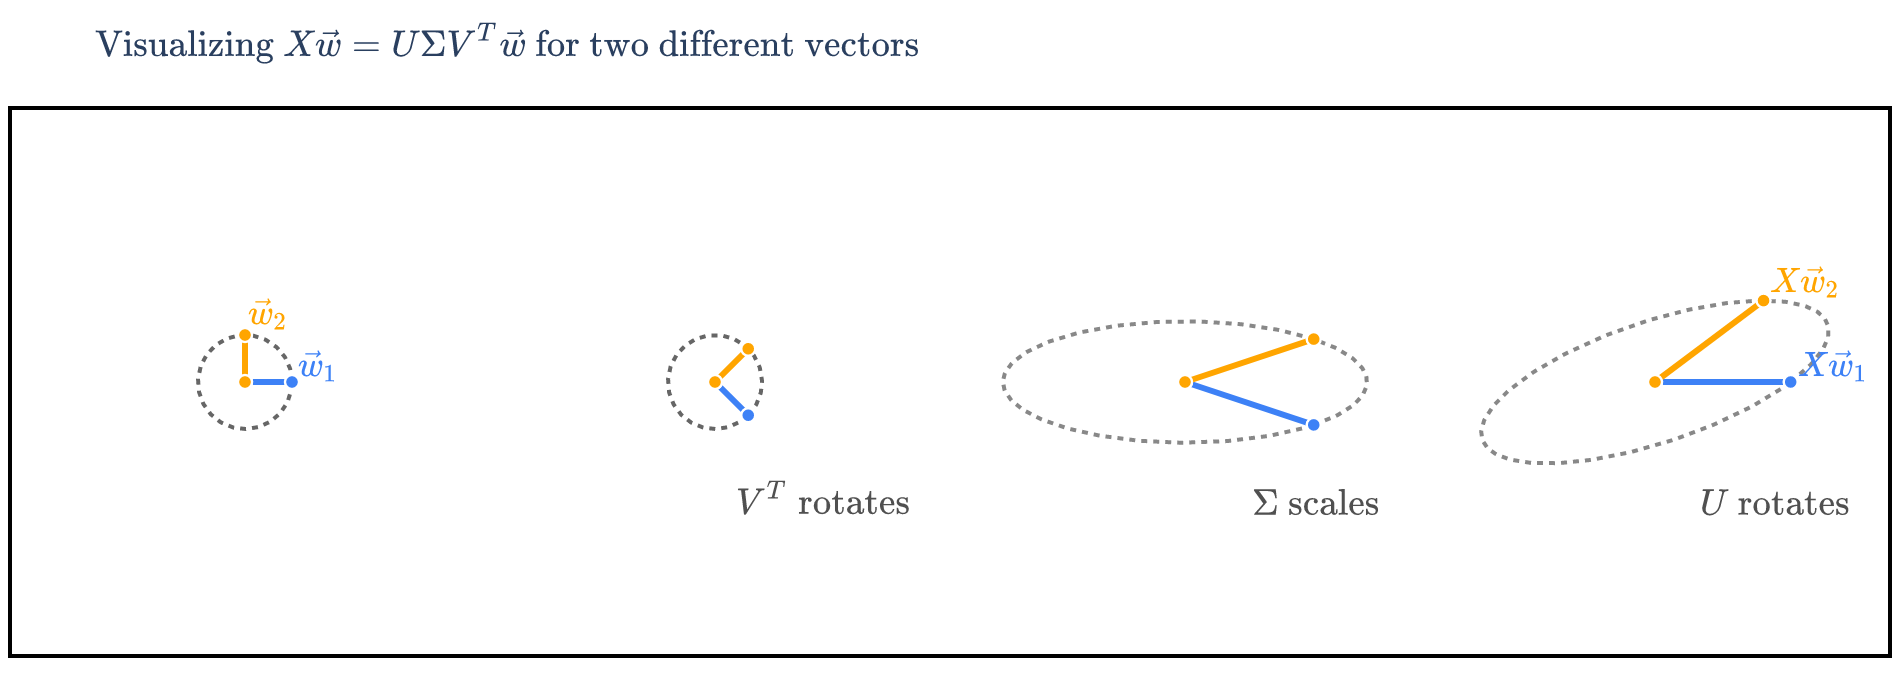

In [7]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_svd_transform_process(
    U, Sigma, Vt,
    w1=None,
    w2=None,
    colors=None,
    show_labels=True,
    names=None,
    xaxis_range=[-1.5, 6],
    yaxis_range=[-3.5, 4.2],
    title="",
    return_fig=False,
):
    # Unit vectors at selected directions
    if w1 is None:
        w1 = np.array([1, 0])                 # Along x axis
    if w2 is None:
        w2 = np.array([0, 1])                 # Along y axis
    w1 = w1 / np.linalg.norm(w1)
    w2 = w2 / np.linalg.norm(w2)

    # Default colors
    colors = colors or ["#3d81f6", "orange"]  # blue, orange

    # Set up the four transforms: w, Vᵗw, ΣVᵗw, UΣVᵗw
    stages = []
    ws_ = [w1, w2]
    stages.append(ws_)
    ws_ = [Vt @ w1, Vt @ w2]
    stages.append(ws_)
    ws_ = [Sigma @ (Vt @ w1), Sigma @ (Vt @ w2)]
    stages.append(ws_)
    ws_ = [U @ (Sigma @ (Vt @ w1)), U @ (Sigma @ (Vt @ w2))]
    stages.append(ws_)

    step_labels = [
        "",
        r"$$V^T\ \text{rotates}$$",
        r"$$\Sigma\ \text{scales}$$",
        r"$$U\ \text{rotates}$$"
    ]
    if not names:
        names = [
            r"Original vectors",
            r"Rotated by $V^T$",
            r"Stretched by $\Sigma$",
            r"Rotated by $U$ ($X\vec w$)"
        ]

    fig = make_subplots(
        rows=1, cols=4, subplot_titles=names, horizontal_spacing=0
    )

    axis_style = dict(
        showgrid=False,
        zeroline=False,
        showline=False,
        mirror=False,
        showticklabels=False,
        ticks="",
    )
    for j in range(4):
        fig.update_xaxes(range=xaxis_range, constrain="domain", **axis_style, row=1, col=j+1)
        fig.update_yaxes(range=yaxis_range, scaleanchor=f"x{j+1}", **axis_style, row=1, col=j+1)

    # Generate unit circle
    t = np.linspace(0, 2 * np.pi, 300)
    circle = np.stack([np.cos(t), np.sin(t)], axis=0)    # shape (2, N)

    # Compute ellipse: start at V^T, apply Sigma, then U
    # This aligns with full SVD sequence:
    # Vt acts on original circle -> rotated
    # Sigma acts on rotated circle -> ellipse, axis-aligned with Σ
    # U acts on ellipse -> final transformed ellipse

    # Get transforms in advance
    circle_Vt     = Vt @ circle
    ellipse_SVt   = Sigma @ circle_Vt
    ellipse_USVt  = U @ ellipse_SVt

    for k, ws in enumerate(stages):
        # Origin point
        fig.add_trace(
            go.Scatter(
                x=[0], y=[0],
                mode="markers",
                marker=dict(size=6, color="#444"),
                hoverinfo="skip",
                showlegend=False,
            ),
            row=1, col=k+1
        )

        # Draw dotted unit circle in 1st frame and 2nd frame
        if k == 0:
            fig.add_trace(
                go.Scatter(
                    x=circle[0], y=circle[1],
                    mode="lines",
                    line=dict(color="#666", width=2, dash='dot'),
                    hoverinfo="skip",
                    showlegend=False
                ),
                row=1, col=k+1
            )
        if k == 1:
            fig.add_trace(
                go.Scatter(
                    x=circle_Vt[0], y=circle_Vt[1],
                    mode="lines",
                    line=dict(color="#666", width=2, dash='dot'),
                    hoverinfo="skip",
                    showlegend=False
                ),
                row=1, col=k+1
            )

        # Draw dotted ellipse (image of unit circle) in 3rd and 4th frames
        if k == 2:
            fig.add_trace(
                go.Scatter(
                    x=ellipse_SVt[0], y=ellipse_SVt[1],
                    mode="lines",
                    line=dict(color="#888", width=2, dash='dot'),
                    hoverinfo="skip",
                    showlegend=False
                ),
                row=1, col=k+1
            )
        if k == 3:
            fig.add_trace(
                go.Scatter(
                    x=ellipse_USVt[0], y=ellipse_USVt[1],
                    mode="lines",
                    line=dict(color="#888", width=2, dash='dot'),
                    hoverinfo="skip",
                    showlegend=False
                ),
                row=1, col=k+1
            )

        for i, w in enumerate(ws):
            # Draw arrow
            fig.add_trace(
                go.Scatter(
                    x=[0, w[0]],
                    y=[0, w[1]],
                    mode="lines+markers",
                    line=dict(
                        width=3,   # Make skinnier
                        color=colors[i],
                        dash="solid"# if k == 0 or k == 3 else "dot"
                    ),
                    marker=dict(
                        size=7,# if k == 0 or k == 3 else 5,
                        color=colors[i],
                        line=dict(width=1.2, color='white')
                    ),
                    hoverinfo="skip",
                    showlegend=False,
                ),
                row=1, col=k+1
            )

            # Label (first and last panels)
            if show_labels and k in [0, 3]:
                lbl = fr"$\vec{{w}}_{{{i+1}}}$" if k == 0 else fr"$X\vec{{w}}_{{{i+1}}}$"
                norm = np.linalg.norm(w)
                shift = 0.10 * w / (norm + 1e-8)
                fig.add_annotation(
                    text=lbl,
                    x=w[0] + shift[0], y=w[1] + shift[1],
                    font=dict(size=17, color=colors[i]),
                    showarrow=False,
                    xanchor="left", yanchor="bottom",
                    row=1, col=k+1
                )

        # Step annotation
        if step_labels[k]:
            xr = xaxis_range if isinstance(xaxis_range[0], (int, float)) else xaxis_range[k]
            yr = yaxis_range if isinstance(yaxis_range[0], (int, float)) else yaxis_range[k]
            x_pos = xr[0] + 0.92*(xr[1] - xr[0])
            y_pos = yr[0] + 0.08*(yr[1] - yr[0]) - 2
            fig.add_annotation(
                text=step_labels[k],
                x=x_pos, y=y_pos,
                font=dict(size=20, color="rgba(80,80,80,0.85)", family="Palatino, serif"),
                showarrow=False,
                xanchor='right', yanchor='bottom',
                row=1, col=k+1
            )

    # Box around all subplots
    fig.add_shape(
        type="rect",
        xref="paper",
        yref="paper",
        x0=0, y0=0,
        x1=1, y1=1,
        line=dict(color="black", width=2),
        fillcolor='rgba(0,0,0,0)',
        layer="above"
    )

    fig.update_layout(
        font=dict(family="Palatino, serif", size=16),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=5, r=5, t=54, b=12),
        width=950, height=340,
        title=title
    )
    if return_fig:
        return fig
    fig.show(renderer='png', scale=2)

# --- SVD for X = [[5, 4], [0, 3]] ---
X = np.array([[5, 4], [0, 3]])
U, S, Vt = np.linalg.svd(X)

Sigma = np.zeros_like(X, dtype=float)
Sigma[:2, :2] = np.diag(S)

# Two orthogonal, unit vectors
w1 = np.array([1, 0])
w2 = np.array([0, 1])
w1 = w1 / np.linalg.norm(w1)
w2 = w2 / np.linalg.norm(w2)

plot_svd_transform_process(
    U, Sigma / np.sqrt(3), Vt,
    w1=w1, w2=w2,
    show_labels=True,
    names=[
        "",
        "",
        "",
        ""
    ],
    xaxis_range=[-5, 5],
    yaxis_range=[-1, 1],
    title=r'$$\text{Visualizing } X\vec w = U\Sigma V^T \vec w \text{ for two different vectors}$$'
)

:::{attention} Rotate, scale, rotate!

The intuition that the SVD decomposes a matrix into a rotation, scaling (stretching), and rotation is crucial for future machine learning applications.
:::

In [Chapter 10.2](./02-low-rank-approximation.ipynb), we'll see how the singular value decomposition can be used to construct low-rank approximations of matrices. A good summary of the SVD is also found at the end of Chapter 10.2.